## Setup: Installation and Imports

In [1]:
!pip install xgboost openpyxl -q
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# LOAD YOUR 3 DATASETS
exports = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/monthly_exports_from_2015.xlsx')
imports = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/monthly_exports_from_2015.xlsx')
trends = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/google_trends_from_2010.xlsx')

print("✅ Datasets loaded:")
print(f"Exports: {len(exports)} months | Imports: {len(imports)} | Trends: {len(trends)}")


✅ Datasets loaded:
Exports: 120 months | Imports: 120 | Trends: 180


## Data Preparation: Feature Engineering and Train-Test Split

In [ ]:
# RELOAD DATASETS
exports = pd.read_excel('monthly_exports_from_2015.xlsx')
imports = pd.read_excel('monthly_imports_major_countries_from_2010.xlsx')
trends = pd.read_excel('google_trends_from_2010.xlsx')

print("✅ Datasets reloaded: 121 + 180 + 180 months")

# 🔥 NULL + YYYYMMDD + NaT PROOF PROCESSING
def safe_date_process(df, df_name):
    print(f"\n🔍 {df_name} DEBUG:")
    print(f"Columns: {list(df.columns)}")
    print(f"First 3 rows:\n{df.head(3)}")

    # REPLACE 'NULL' TEXT → Actual NaN
    for col in df.columns:
        df[col] = df[col].replace('NULL', np.nan)
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Try first 3 columns for dates
    for i, col in enumerate(df.columns[:3]):
        print(f"Testing '{col}': {df[col].iloc[0]}")

        # YYYYMMDD (20150101)
        try:
            test_dates = pd.to_datetime(df[col], format='%Y%m%d', errors='coerce')
            valid = test_dates.notna().sum()
            print(f"  YYYYMMDD: {valid}/{len(df)}")
            if valid > len(df)*0.7:
                df['date'] = test_dates
                first_valid = df['date'].dropna()
                if len(first_valid) > 0:
                    print(f"✅ YYYYMMDD '{col}' → {first_valid.iloc[0]:%Y-%m}")
                break
                continue
        except:
            pass

        # Auto parse
        try:
            test_dates = pd.to_datetime(df[col], errors='coerce', dayfirst=True)
            valid = test_dates.notna().sum()
            print(f"  Auto: {valid}/{len(df)}")
            if valid > len(df)*0.7:
                df['date'] = test_dates
                first_valid = df['date'].dropna()
                if len(first_valid) > 0:
                    print(f"✅ Auto '{col}' → {first_valid.iloc[0]:%Y-%m}")
                break
        except:
            pass

    # Sequential months
    if 'date' not in df.columns or df['date'].isna().all():
        df['date'] = pd.date_range('2010-01-01', periods=len(df), freq='MS')
        print("⚠️ Sequential dates: 2010-01 → ...")

    df.set_index('date', inplace=True)
    print(f"✅ {df_name}: {len(df)} rows OK")
    return df

# PROCESS ALL FILES
exports = safe_date_process(exports, "EXPORTS")
imports = safe_date_process(imports, "IMPORTS")
trends = safe_date_process(trends, "TRENDS")

# MERGE + CLEAN NULLs
master_df = exports.join(imports, how='outer').join(trends, how='outer')
print(f"\n🔍 MASTER before cleaning: {len(master_df)} months")

# REPLACE NULL → 0 + Forward fill
master_df = master_df.replace('NULL', np.nan)
master_df = master_df.fillna(method='ffill').fillna(0)
print(f"✅ MASTER after NULL handling: {len(master_df)} months × {len(master_df.columns)} vars")

# FEATURES (Safe version)
master_df['month'] = master_df.index.month

# SL Exports lags (core target)
if 'SL_Exports_tons' in master_df.columns:
    master_df['SL_lag1'] = master_df['SL_Exports_tons'].shift(1)
    master_df['SL_lag3'] = master_df['SL_Exports_tons'].shift(3)
    master_df['SL_lag12'] = master_df['SL_Exports_tons'].shift(12)

# Safe competitors
if 'China_Exports_tons' in master_df.columns:
    master_df['China_lag1'] = master_df['China_Exports_tons'].shift(1)

if 'Indonesia_Exports_tons' in master_df.columns:
    master_df['Indonesia_lag1'] = master_df['Indonesia_Exports_tons'].shift(1)

if 'Viet Nam_Exports_tons' in master_df.columns:
    master_df['VN_lag1'] = master_df['Viet Nam_Exports_tons'].shift(1)

eu_cols = [c for c in ['Germany','France','Netherlands'] if c in master_df.columns]
if eu_cols:
    master_df['EU_demand'] = master_df[eu_cols].sum(axis=1).shift(1)

# Safe trends
trend_cols = [col for col in master_df.columns if 'ceylon' in str(col).lower()]
if trend_cols:
    master_df['ceylon_trends'] = master_df[trend_cols[:2]].mean(axis=1).shift(1)

# Clean final dataset
master_df = master_df.dropna()
print(f"✅ FINAL CLEAN DATASET: {len(master_df)} months")

# Features list (your original)
features = ['month','SL_lag1','SL_lag12','China_lag1','Indonesia_lag1','VN_lag1',
           'USA_lag1','EU_demand','ceylon_trends']
available_features = [f for f in features if f in master_df.columns]

X = master_df[available_features]
y = master_df['SL_Exports_tons']

# 70/30 split
split = int(len(X) * 0.7)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"\n✅ {len(available_features)} FEATURES: {available_features}")
print(f"✅ TRAIN: {len(X_train)} months | TEST: {len(X_test)} months")
print("✅ XGBoost READY! 🎯")

## Model Training: XGBoost Regressor


🏆 Xgboost CEYLON CINNAMON EXPORT DEMAND FORECAST
📊 Test Period: 2020-10 → 2024-12
✅ Test MAE: 108 tons/month
✅ Test MAPE: 7.5%
✅ Test R²: 71.8% variance explained
📈 Test samples: 51 months

📊 TOP DEMAND DRIVERS:
          feature  importance
1         SL_lag1       0.505
4  Indonesia_lag1       0.391
2        SL_lag12       0.071
5         VN_lag1       0.009
3      China_lag1       0.008
7   ceylon_trends       0.007
0           month       0.004
6       EU_demand       0.004


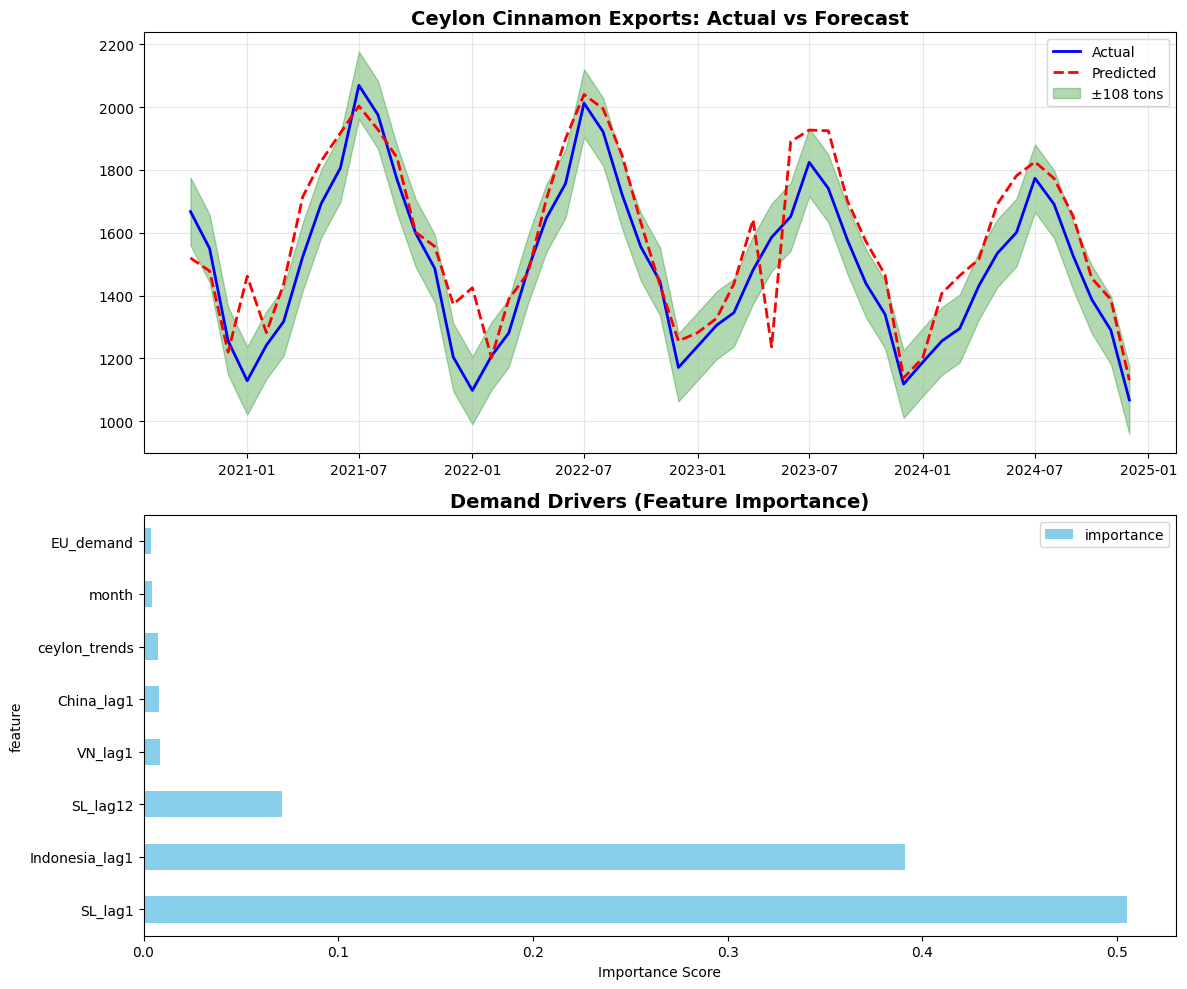

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the XGBoost Regressor model
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
r2 = r2_score(y_test, y_pred) * 100

print("\n" + "="*80)
print("🏆 Xgboost CEYLON CINNAMON EXPORT DEMAND FORECAST")
print("="*80)
print(f"📊 Test Period: {X_test.index[0]:%Y-%m} → {X_test.index[-1]:%Y-%m}")
print(f"✅ Test MAE: {mae:.0f} tons/month")
print(f"✅ Test MAPE: {mape:.1f}%")
print(f"✅ Test R²: {r2:.1f}% variance explained")
print(f"📈 Test samples: {len(y_test)} months")
print("="*80)

# 🔥 FIXED FEATURE IMPORTANCE (using available_features)
importance_df = pd.DataFrame({
    'feature': available_features,  # ← FIXED: Use available_features
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 TOP DEMAND DRIVERS:")
print(importance_df.round(3))

# PLOT RESULTS
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Actual vs Predicted
ax1.plot(y_test.index, y_test, 'b-', label='Actual', linewidth=2)
ax1.plot(y_test.index, y_pred, 'r--', label='Predicted', linewidth=2)
ax1.fill_between(y_test.index,
                y_test - mae, y_test + mae,
                alpha=0.3, color='green', label=f'±{mae:.0f} tons')
ax1.set_title('Ceylon Cinnamon Exports: Actual vs Forecast', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Feature Importance
ax2 = importance_df.plot.barh(x='feature', y='importance', ax=ax2, color='skyblue')
ax2.set_title('Demand Drivers (Feature Importance)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

## Model Training: Random Forest Regressor


🌲 RANDOM FOREST CINNAMON DEMAND FORECAST
📊 Test Period: 2020-10 → 2024-12
✅ Test MAE: 119 tons/month
✅ Test MAPE: 8.1%
✅ Test R²: 72.1% variance explained
📈 Test samples: 51 months

📊 RANDOM FOREST DEMAND DRIVERS:
          feature  importance
5         VN_lag1       0.324
1         SL_lag1       0.302
4  Indonesia_lag1       0.278
2        SL_lag12       0.084
7   ceylon_trends       0.006
0           month       0.003
3      China_lag1       0.002
6       EU_demand       0.001


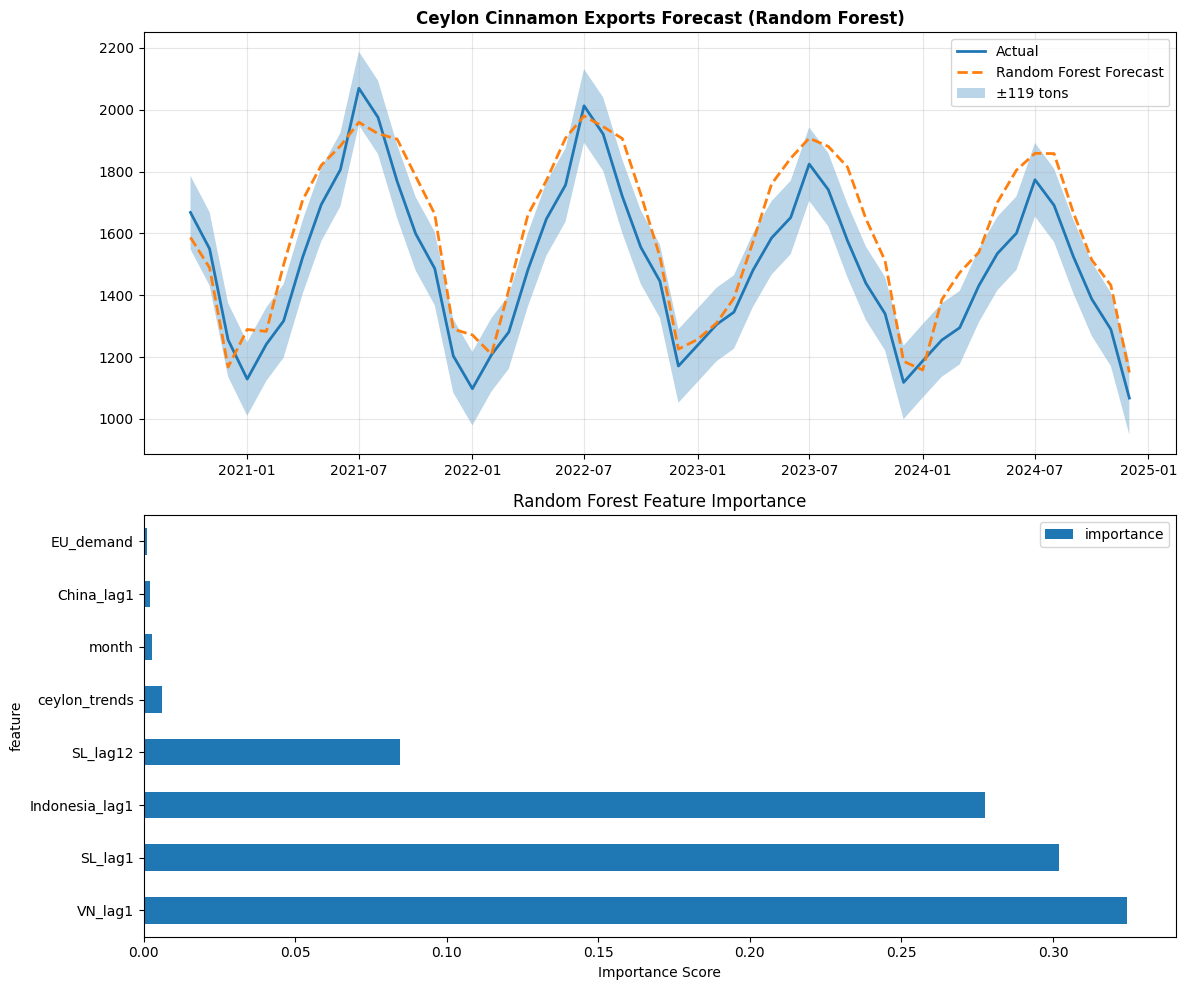

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd

# Train Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf) * 100
r2_rf = r2_score(y_test, y_pred_rf) * 100

print("\n" + "="*80)
print("🌲 RANDOM FOREST CINNAMON DEMAND FORECAST")
print("="*80)
print(f"📊 Test Period: {X_test.index[0]:%Y-%m} → {X_test.index[-1]:%Y-%m}")
print(f"✅ Test MAE: {mae_rf:.0f} tons/month")
print(f"✅ Test MAPE: {mape_rf:.1f}%")
print(f"✅ Test R²: {r2_rf:.1f}% variance explained")
print(f"📈 Test samples: {len(y_test)} months")
print("="*80)

# Feature importance
importance_rf = pd.DataFrame({
    'feature': available_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 RANDOM FOREST DEMAND DRIVERS:")
print(importance_rf.round(3))

# Plot results
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,10))

# Actual vs Predicted
ax1.plot(y_test.index, y_test, label="Actual", linewidth=2)
ax1.plot(y_test.index, y_pred_rf, '--', label="Random Forest Forecast", linewidth=2)

ax1.fill_between(
    y_test.index,
    y_test - mae_rf,
    y_test + mae_rf,
    alpha=0.3,
    label=f"±{mae_rf:.0f} tons"
)

ax1.set_title("Ceylon Cinnamon Exports Forecast (Random Forest)", fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Feature importance
importance_rf.plot.barh(x='feature', y='importance', ax=ax2)
ax2.set_title("Random Forest Feature Importance")
ax2.set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

## Model Training: LightGBM Regressor

In [ ]:
!pip install lightgbm -q

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005817 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 203
[LightGBM] [Info] Number of data points in the train set: 117, number of used features: 8
[LightGBM] [Info] Start training from score 810.912767
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

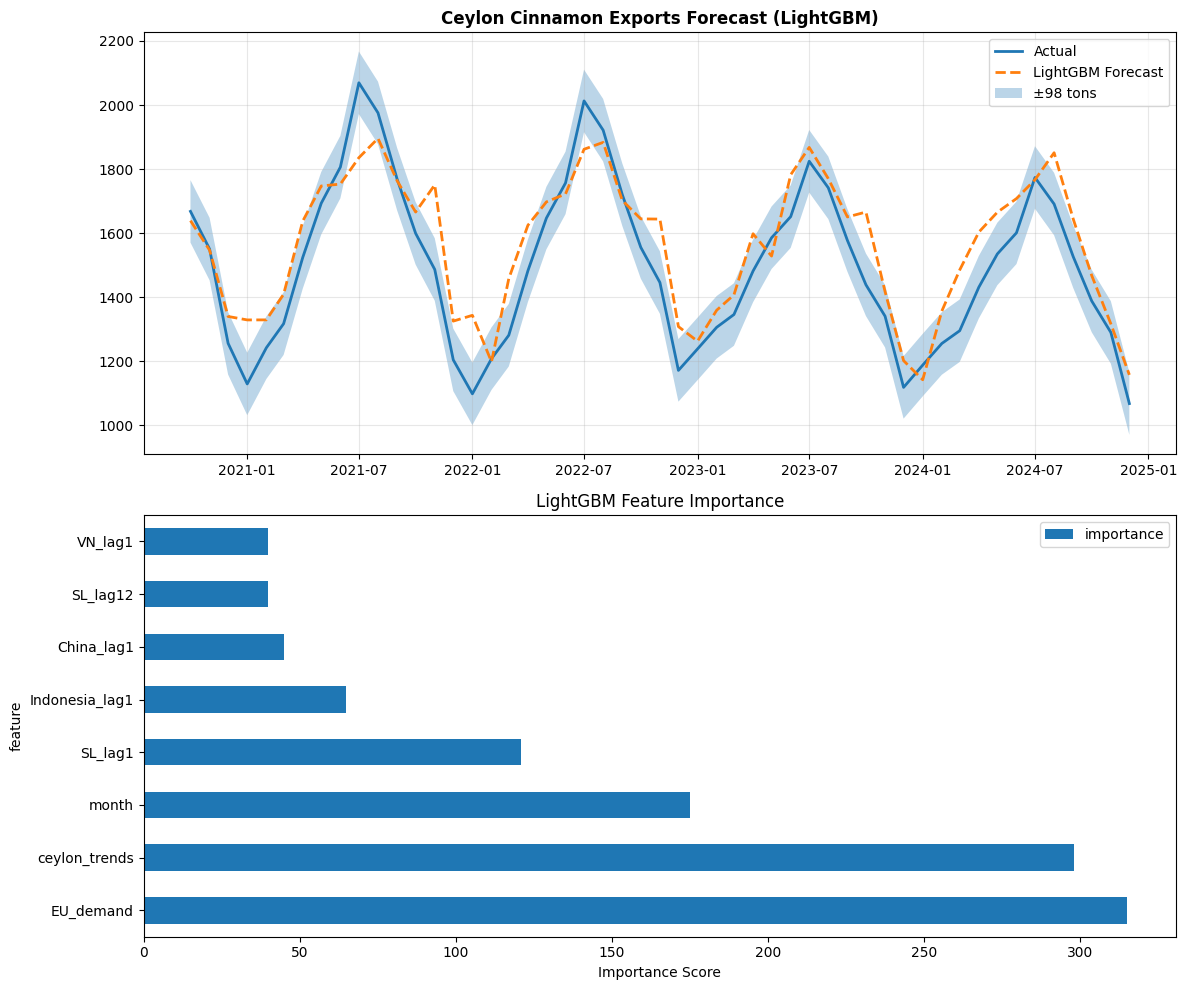

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt

# Train LightGBM model
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train, y_train)

# Predictions
y_pred_lgb = lgb_model.predict(X_test)

# Evaluation metrics
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
mape_lgb = mean_absolute_percentage_error(y_test, y_pred_lgb) * 100
r2_lgb = r2_score(y_test, y_pred_lgb) * 100

print("\n" + "="*80)
print("⚡ LIGHTGBM CINNAMON DEMAND FORECAST")
print("="*80)
print(f"📊 Test Period: {X_test.index[0]:%Y-%m} → {X_test.index[-1]:%Y-%m}")
print(f"✅ Test MAE: {mae_lgb:.0f} tons/month")
print(f"✅ Test MAPE: {mape_lgb:.1f}%")
print(f"✅ Test R²: {r2_lgb:.1f}% variance explained")
print(f"📈 Test samples: {len(y_test)} months")
print("="*80)

# Feature importance
importance_lgb = pd.DataFrame({
    'feature': available_features,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 LIGHTGBM DEMAND DRIVERS:")
print(importance_lgb.round(3))

# Plot results
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,10))

# Actual vs Predicted
ax1.plot(y_test.index, y_test, label="Actual", linewidth=2)
ax1.plot(y_test.index, y_pred_lgb, '--', label="LightGBM Forecast", linewidth=2)

ax1.fill_between(
    y_test.index,
    y_test - mae_lgb,
    y_test + mae_lgb,
    alpha=0.3,
    label=f"±{mae_lgb:.0f} tons"
)

ax1.set_title("Ceylon Cinnamon Exports Forecast (LightGBM)", fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Feature importance
importance_lgb.plot.barh(x='feature', y='importance', ax=ax2)
ax2.set_title("LightGBM Feature Importance")
ax2.set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

In [ ]:
# DEFINE REGIONS (based on your imports data)
regions = {
    'North America': ['USA', 'Mexico'],  # Mexico might be in imports as separate
    'Europe': ['Germany', 'France', 'Netherlands', 'United Kingdom', 'Spain'],
    'South America': ['Peru', 'Colombia', 'Chile', 'Argentina', 'Bolivia (Plurinational State of)'],
    'Asia': ['India', 'Japan'],
    'Latin America': ['Guatemala']  # Often grouped separately
}

results_region = {}

for region_name, countries in regions.items():
    print(f"\n🌎 {region_name.upper()} DEMAND")
    print("-" * 50)

    # Sum imports for this region
    region_imports = pd.Series(0, index=master_df.index)
    valid_countries = []

    for country in countries:
        if country in master_df.columns:
            region_imports += master_df[country].fillna(0)
            valid_countries.append(country)

    if len(valid_countries) == 0:
        print(f"⚠️ No data for {region_name}")
        continue

    print(f"Countries: {valid_countries}")

    # Target = Region total imports
    y_region = region_imports

    # Features (same as total SL model)
    features_region = [f for f in available_features + ['month_sin', 'comp_sl_ratio']
                      if f in master_df.columns]
    X_region = master_df[features_region].dropna()
    y_region = y_region.loc[X_region.index].dropna()

    # Align
    valid_idx = X_region.index.intersection(y_region.index)
    X_region = X_region.loc[valid_idx]
    y_region = y_region.loc[valid_idx]

    if len(y_region) < 20:
        print(f"⚠️ {region_name}: Too few points ({len(y_region)})")
        continue

    # 70/30 split
    split = int(len(X_region) * 0.7)
    X_train_r, X_test_r = X_region.iloc[:split], X_region.iloc[split:]
    y_train_r, y_test_r = y_region.iloc[:split], y_region.iloc[split:]

    # Train region model
    scaler_r = StandardScaler()
    X_train_rs = scaler_r.fit_transform(X_train_r)
    X_test_rs = scaler_r.transform(X_test_r)

    model_region = xgb.XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=4, random_state=42)
    model_region.fit(X_train_rs, y_train_r)

    # Results
    y_pred_r = model_region.predict(X_test_rs)
    mape_r = mean_absolute_percentage_error(y_test_r, y_pred_r) * 100
    mae_r = mean_absolute_error(y_test_r, y_pred_r)

    results_region[region_name] = {'MAPE': mape_r, 'MAE': mae_r, 'test_months': len(y_test_r)}

    print(f"✅ {region_name}: **{mape_r:.1f}% MAPE** | {mae_r:.0f} tons | {len(y_test_r)}mo")
    print(f"   Test: {X_test_r.index[0]:%Y-%m} → {X_test_r.index[-1]:%Y-%m}")

    # Plot region
    plt.figure(figsize=(12, 5))
    plt.plot(y_test_r.index, y_test_r, 'g-', label='Actual', linewidth=3)
    plt.plot(y_test_r.index, y_pred_r, 'r--', label=f'Forecast ({mape_r:.1f}% MAPE)', linewidth=3)
    plt.title(f'{region_name} Cinnamon Demand Forecast', fontweight='bold', fontsize=14)
    plt.ylabel('Total Tons'); plt.xlabel('Date')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# SUMMARY TABLE
print("\n" + "="*60)
print("🏆 REGION DEMAND SUMMARY")
print("="*60)
region_df = pd.DataFrame(results_region).T
print(region_df.round(1))

best_region = region_df['MAPE'].idxmin()
print(f"\n🎯 BEST REGION: {best_region} ({region_df.loc[best_region, 'MAPE']:.1f}% MAPE)")

print("\n✅ REGION MODELS COMPLETE!")
print("📋 Paper ready: Total SL + Countries + Regions!")

ARIMA (Statsmodels) - **Classical**